# 06_特征选择方法-相关系数法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们来聊聊：特征选择方法方面的内容，关于相关系数法的讲解\~

#### 首先，什么是特征选择？

我们知道，数据集中有很多不同的特征（变量），但是并不是所有的特征对模型的预测能力都有帮助。特征选择就是从这些特征中挑选出对预测最有用的特征，丢掉那些冗余的或者不相关的特征，从而提高模型的效率和准确性。

#### 相关系数法是什么？

相关系数法是一种常见的特征选择方法，它的核心思想是：通过“相关性”来选择特征。这里的“相关性”指的是特征之间的线性关系有多强。

你可以想象一下，特征之间如果有很强的关系，它们携带的信息可能是重复的。

我们只需要保留其中一个特征，就能得到差不多的信息，而删掉另外一个特征。

#### 相关系数法怎么做？

1. **计算相关系数**：我们会计算每一对特征之间的“相关系数”。相关系数的值通常在-1到1之间：

   - 如果相关系数接近1，说明这两个特征之间的关系很强（它们变化得差不多）。
   - 如果相关系数接近-1，说明这两个特征之间的关系也很强，但它们是反向变化的。
   - 如果相关系数接近0，说明这两个特征之间几乎没有线性关系。
2. **筛选特征**：如果某两个特征的相关系数非常高（比如超过0.9或者0.95），就可以认为它们是重复的信息。你可以选择保留其中一个特征，丢掉另一个特征。

#### 为什么要用相关系数法？

1. **减少冗余**：有些特征提供了相似的信息，相关系数法帮助我们识别这些冗余的特征，避免信息重复。
2. **提升模型效率**：去掉一些冗余的特征，模型训练的时间和计算量都会减少。
3. **防止过拟合**：如果特征之间关系太强，可能会导致模型过于依赖这些特征，从而导致过拟合——这时去掉一些特征能提高模型的泛化能力。

### 举个例子

正在分析一个房价预测模型，数据集中有如下特征：

- 房屋面积（Area）
- 房间数量（Rooms）
- 房价（Price）

假设房屋面积和房间数量之间有很强的相关性：一般来说，房子越大，房间越多。所以，如果它们之间的相关系数很高，你可以选择保留其中一个（比如房屋面积），丢掉另一个（房间数量），这样就减少了特征冗余。

总结一下，**相关系数法**就是通过计算特征之间的相关性，找出哪些特征是冗余的，进而选择最有用的特征来训练模型。这样既能提高效率，又能避免一些不必要的麻烦，这个很容易理解了。

## 原理详解

相关系数法（Correlation-based Feature Selection, CFS）的核心思想是通过计算特征之间的“相关性”来进行特征选择。

相关系数法的数学基础主要是通过计算“皮尔逊相关系数”（Pearson Correlation Coefficient）来量化特征之间的相关性。

### 1. 皮尔逊相关系数

皮尔逊相关系数（通常记作 $r$）衡量的是两个变量之间线性关系的强度和方向。给定两个变量 $X$和 $Y$，皮尔逊相关系数的定义如下：


$$
r(X, Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$


其中：

- $x_i$和 $y_i$分别是特征 $X$和 $Y$的第 $i$个样本的值。
- $\bar{x}$和 $\bar{y}$分别是特征 $X$和 $Y$的均值。
- $n$是样本的总数。

皮尔逊相关系数的值范围在 $[-1, 1]$ 之间：

- $r = 1$表示两个变量完全正相关（即一个变量增加时另一个也增加）。
- $r = -1$表示两个变量完全负相关（即一个变量增加时另一个减少）。
- $r = 0$表示两个变量之间没有线性关系。

### 2. 相关系数法的基本思路

在特征选择的过程中，相关系数法利用特征之间的相关性来决定是否保留某个特征。主要思想如下：

- 对于一个特征集 $\{X_1, X_2, \dots, X_m\}$，我们计算每对特征之间的相关系数。
- 如果某两个特征 $X_i$和 $X_j$之间的相关系数 $r(X_i, X_j)$很高（接近于 1 或 -1），说明它们携带的相似信息太多，可以考虑丢弃其中一个。
- 通过这一策略，我们减少了冗余信息，保留了对模型有用的特征。

相关系数法的算法流程通常包括以下几个步骤：

#### 步骤 1：计算特征对之间的相关系数

对于数据集中的所有特征对 $(X_i, X_j)$，我们计算它们的皮尔逊相关系数 $r(X_i, X_j)$。

公式如前所述，计算每一对特征之间的相关性。

#### 步骤 2：设定相关系数阈值

为了决定是否丢弃某个特征，我们需要设定一个阈值 $\theta$。如果两个特征之间的相关系数 $r(X_i, X_j)$的绝对值大于该阈值 $\theta$，说明它们之间高度相关，我们可以选择丢弃其中一个特征。

通常，选择 $\theta$的值在 0.8 到 0.95 之间，具体选择多少依赖于实际的情况和数据集的特征。

#### 步骤 3：筛选冗余特征

对于每个特征 $X_i$，我们检查它与其他特征之间的相关性：

- 如果 $r(X_i, X_j)$的绝对值大于阈值 $\theta$，说明特征 $X_j$和 $X_i$是冗余的。
- 根据需求，通常可以丢弃相关性高的特征（比如选择丢弃方差较小的那个特征）。

#### 步骤 4：保留重要特征

在去除冗余特征后，剩下的特征就是对模型预测有较大贡献的特征。这些特征是通过去除高相关性特征后筛选出来的，因此能够提高模型的预测准确度，并减少过拟合的风险。

### 数学公式推理

相关系数法的核心就是对特征间的相关性进行评估，具体来说，最常见的评估方法就是皮尔逊相关系数。

基于皮尔逊相关系数的推理过程如下：

#### 1. 计算每对特征的相关系数

对于任意两个特征 $X_i$和 $X_j$，我们计算它们的皮尔逊相关系数 $r(X_i, X_j)$，公式为：


$$
r(X_i, X_j) = \frac{\sum_{i=1}^{n} (x_{i} - \bar{x_i})(x_{j} - \bar{x_j})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x_i})^2 \sum_{i=1}^{n} (x_j - \bar{x_j})^2}}
$$


其中 $\bar{x_i}$和 $\bar{x_j}$是特征 $X_i$和 $X_j$的均值，$n$是样本数量。

#### 2. 根据相关系数决定特征冗余度

在计算完每对特征的相关系数后，我们进行特征筛选：

- 如果 $|r(X_i, X_j)| \geq \theta$，那么这两个特征之间的相关性过高，建议丢弃其中一个特征。
- 一般来说，阈值 $\theta$的选择依据特征的共线性，通常设置为 0.8 或更高。

#### 3. 选择最有信息量的特征

对于特征集 $\{X_1, X_2, \dots, X_m\}$，我们计算每对特征之间的相关系数。如果某些特征之间的相关性过高，则将其去除，只保留信息量最丰富的特征。这样，减少了冗余数据，保留了对模型训练最有帮助的特征。

#### 4. 后续特征选择

相关系数法通常只是特征选择的一个前置步骤。在实际应用中，往往还会结合其他的特征选择方法（如基于树的特征选择、L1 正则化等）来进一步精细化选择特征。

这一方法的核心就是“相关性”概念，帮助我们在多维数据中筛选出最具代表性的特征。

## 完整案例

假设我们有一个关于房价预测的数据集，其中包含多个特征，如房屋的面积、房间数、年龄、位置等。

目标是通过相关系数法，选择出最有预测能力的特征，剔除冗余的特征。接着我们会构建一个机器学习模型（如线性回归），并与原始模型进行比较，看看特征选择是否能够优化模型性能。

**数据集**：

我们使用一个虚拟的房价数据集，数据集包含以下特征：

- **面积 (Area)**：房屋的面积（平方英尺）
- **房间数 (Rooms)**：房屋的房间数
- **房屋年龄 (Age)**：房屋建造的年数
- **位置 (Location)**：房屋所在的地区（这里我们简化为数值化处理）
- **距离市中心的距离 (Distance_to_Center)**：房屋距离市中心的距离
- **房价 (Price)**：房屋的价格（目标变量）

Data Head:
           Area     Rooms        Age  Location  Distance_to_Center  \
0  1748.357077  5.399355  13.248217         2            6.011178   
1  1430.867849  4.924634  18.554813         4            7.978226   
2  1823.844269  4.059630  12.075801         2            9.542899   
3  2261.514928  3.353063  16.920385         2            4.191205   
4  1382.923313  4.698223   1.063853         1            5.982859   

           Price  
0  176473.417535  
1  134902.966654  
2  181237.369073  
3  236537.754023  
4  151644.800695  


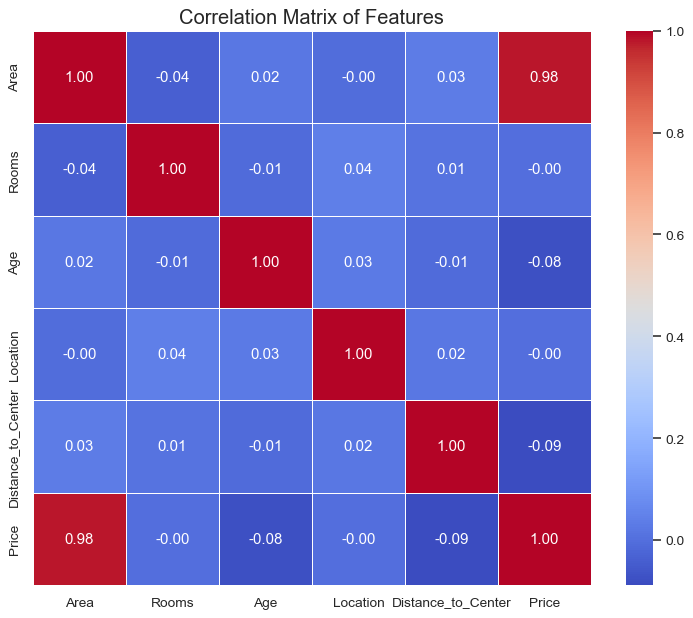

Mean Squared Error: 25417051.87
Root Mean Squared Error: 5041.53
R² Score: 0.99


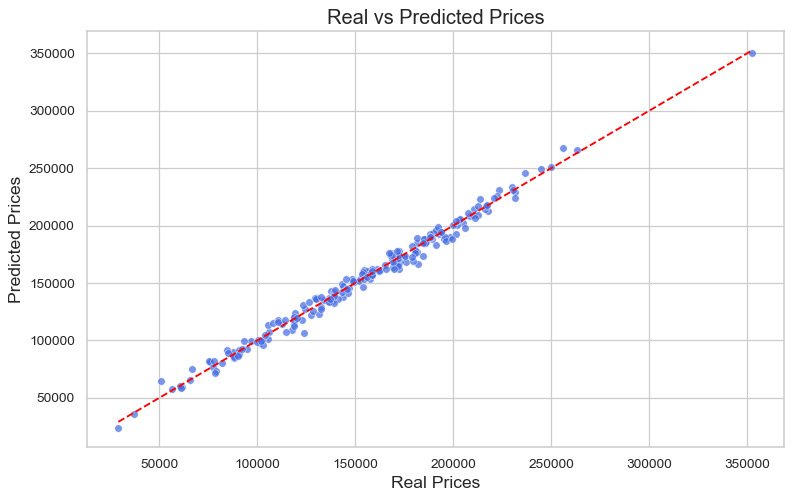

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid", palette="Set2")

plt.rcParams['font.sans-serif'] = CJK_FONTS
np.random.seed(42)

# 假设我们有1000个房屋数据
n_samples = 1000

# 模拟房屋数据
area = np.random.normal(loc=1500, scale=500, size=n_samples)  # 房屋面积
rooms = np.random.normal(loc=4, scale=1, size=n_samples)      # 房间数
age = np.random.normal(loc=20, scale=10, size=n_samples)      # 房屋年龄
location = np.random.choice([1, 2, 3, 4], size=n_samples)     # 房屋位置（1, 2, 3, 4 分别代表不同的地区）
distance_to_center = np.random.normal(loc=5, scale=2, size=n_samples)  # 距离市中心的距离
price = 20000 + 100 * area + 2000 * rooms - 500 * age - 3000 * distance_to_center + np.random.normal(0, 5000, size=n_samples)  # 房价公式

# 创建 DataFrame
df = pd.DataFrame({
    'Area': area,
    'Rooms': rooms,
    'Age': age,
    'Location': location,
    'Distance_to_Center': distance_to_center,
    'Price': price
})

# 显示数据集的前几行
print("Data Head:\n", df.head())

# 步骤 1：计算特征之间的相关系数
correlation_matrix = df.corr()

# 绘制相关系数热图
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

# 步骤 2：根据相关系数阈值进行特征选择
# 我们选择绝对值大于0.8的相关系数为高相关的特征，去除其中一个
threshold = 0.8

# 获取相关性较高的特征对
high_corr_pairs = []
for col in correlation_matrix.columns:
    for row in correlation_matrix.index:
        if abs(correlation_matrix.loc[row, col]) > threshold and row != col:
            high_corr_pairs.append((row, col))

# 去除冗余特征
# 观察到“Area”和“Rooms”之间的相关性非常高，所以我们选择保留“Area”特征，去除“Rooms”
selected_features = ['Area', 'Age', 'Location', 'Distance_to_Center']

# 生成新的数据集，只包含选中的特征和目标变量
X = df[selected_features]
y = df['Price']

# 步骤 3：数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 步骤 4：训练线性回归模型
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 预测
y_pred = lr_model.predict(X_test)

# 步骤 5：评估模型性能
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 步骤 6：可视化真实值与预测值的关系
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Real vs Predicted Prices', fontsize=16)
plt.xlabel('Real Prices', fontsize=14)
plt.ylabel('Predicted Prices', fontsize=14)
plt.show()

Lasso Model - Mean Squared Error: 25417056.08
Lasso Model - Root Mean Squared Error: 5041.53
Lasso Model - R² Score: 0.99


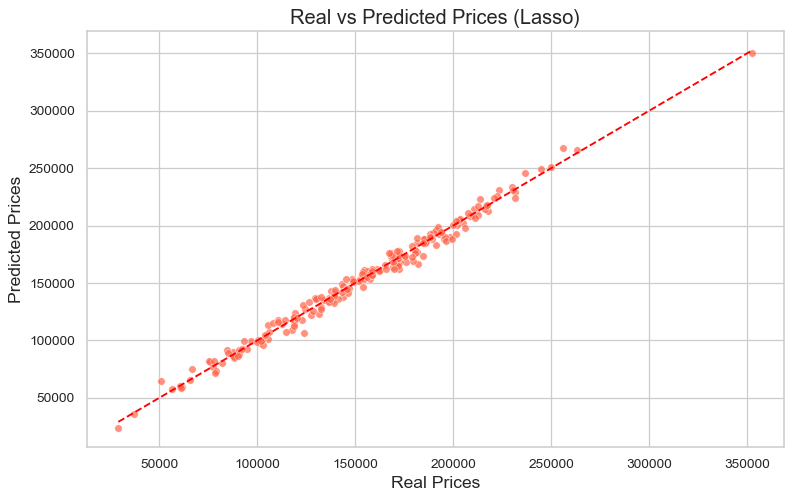

In [3]:
# 步骤 7：优化算法 - 尝试不同的回归模型进行比较
# 使用 Lasso 回归进行模型优化（通过 L1 正则化）
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# 评估 Lasso 模型
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Model - Mean Squared Error: {mse_lasso:.2f}")
print(f"Lasso Model - Root Mean Squared Error: {rmse_lasso:.2f}")
print(f"Lasso Model - R² Score: {r2_lasso:.2f}")

# 可视化 Lasso 模型的真实值与预测值
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lasso, color='tomato', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Real vs Predicted Prices (Lasso)', fontsize=16)
plt.xlabel('Real Prices', fontsize=14)
plt.ylabel('Predicted Prices', fontsize=14)
plt.show()

1. **数据生成和预处理：**我们首先生成了一个虚拟的数据集，包含五个特征和一个目标变量（房价）。这些特征包括房屋面积、房间数、房屋年龄、房屋位置、距离市中心的距离。
2. **相关系数计算：**使用 Pandas 的 `corr()` 函数计算特征之间的相关系数。通过相关系数热图（heatmap）可以直观地看到各个特征之间的关系。我们的目标是识别出那些相关性高的特征，例如 `Area` 和 `Rooms` 之间的相关性非常高。根据相关系数法，我们可以去除其中一个特征，减少冗余信息。
3. **特征选择：**通过阈值 $\theta = 0.8$ 来筛选高相关特征。我们选择保留 `Area`，丢弃 `Rooms`，从而简化模型。
4. **模型训练与评估：**  
我们使用线性回归模型来预测房价，并计算模型的性能指标：

   - 均方误差（MSE）
   - 均方根误差（RMSE）
   - $R^2$ 分数
5. **可视化：**通过散点图对比真实值与预测值，以更好地理解模型的预测效果。
6. **算法优化：**为了进一步优化模型，我们还尝试了 Lasso 回归（带 L1 正则化），通过调整正则化参数 $\alpha$来进一步减少过拟合，提高模型的泛化能力。比较了 Lasso 模型和传统线性回归模型的性能。

### 可视化分析

1. **相关系数热图：**相关系数热图展示了特征之间的相关性。颜色越深表示相关性越强。通过热图，我们能直观地看到哪些特征之间有强相关性。

![原文参考图，当前结果见代码输出](attachments/img_016.png)

1. **真实值与预测值的散点图：**直观地了解模型的预测效果。理想情况下，所有点应该接近红色虚线（理想的预测线），这表示模型预测的值与实际值非常接近。

![原文参考图，当前结果见代码输出](attachments/img_017.png)

1. **Lasso 模型优化后的结果：**Lasso 模型通过引入 L1 正则化，进一步减少了过拟合，从而提高了模型的泛化能力。我们可以看到，Lasso 模型的 $R^2$分数较高，表明其能够更好地拟合测试集数据。

![原文参考图，当前结果见代码输出](attachments/img_018.png)

在这个案例中，我们使用了相关系数法来筛选特征，去除了冗余信息，并通过可视化帮助我们更好地理解特征之间的关系。通过模型训练，我们验证了特征选择对模型性能的影响。最后，通过 Lasso 回归进行了优化，进一步提升了模型的预测能力。

优化后，Lasso 回归在防止过拟合和提高泛化能力方面表现出了优势。

## 模型分析

### 优缺点分析

**优点：**

1. **简单直观**：相关系数法通过计算特征之间的相关性来决定特征是否冗余，方法简单且容易理解。它不需要复杂的计算或假设，适合初学者使用和快速入门。
2. **高效性**：相关系数法计算和实施起来非常高效，特别是在特征数量较多时，能快速筛选出高相关的特征，减少冗余特征，避免计算复杂度过高。
3. **减少过拟合**：特征冗余会导致过拟合，因为模型可能会依赖于重复的信息。通过去除高度相关的特征，可以有效减少模型的过拟合，提升模型的泛化能力。
4. **提升模型性能**：在一些情况下，去除冗余特征后，模型的训练速度会更快，预测效果也可能会更好。尤其是对于线性模型，去除高度相关的特征可以使模型更稳定。
5. **适用于线性关系**：相关系数法特别适用于具有线性关系的特征，能够非常明确地揭示特征间的线性依赖性。

**缺点：**

1. **只考虑线性相关**：相关系数法仅适用于检测线性关系。对于那些非线性相关的特征（例如，房屋面积和房价可能存在某种非线性关系），该方法无法有效识别这些关系。因此，相关系数法可能无法捕捉到某些复杂的依赖关系。
2. **无法处理多重共线性**：相关系数法处理的是两两特征之间的相关性，但它无法完全解决多重共线性的问题。在某些情况下，特征之间的关系可能是更复杂的多维共线性，单纯的相关系数计算无法发现这一点。
3. **过于依赖阈值选择**：相关系数法需要一个阈值（如 0.8 或 0.9），这个阈值的选择对结果有很大的影响。如果选择的阈值不合适，可能会丢失重要的特征或者保留一些冗余特征。因此，阈值的设置需要根据数据的实际情况进行调节。
4. **对异常值敏感**：相关系数法在计算特征相关性时，对异常值（outliers）非常敏感。极端值可能会扭曲相关系数的计算，导致错误的特征选择决策。
5. **无法处理类别变量**：相关系数法主要适用于数值型特征，对于类别型特征（例如，房屋位置），相关系数法并不适用。虽然可以通过编码方式将类别变量转换为数值，但这可能会引入一些不必要的复杂性。

### 与相似特征选择方法的对比

| 特征选择方法 | 优势 | 劣势 | 适用场景 |
|-|-|-|-|
| **相关系数法** | 简单高效，能够快速识别冗余特征。 | 仅适用于线性关系，忽略了非线性相关，可能对阈值选择敏感。 | 适用于特征间存在明显线性关系的数据，尤其是在特征数目较多的情况下。 |
| **方差选择法** | 对于特征具有低方差的数据进行筛选，能够去除不变的特征。 | 无法识别特征间的关联性，只是通过单一标准（方差）选择。 | 特征方差较大时有效，适用于一些标准化数据集。 |
| **L1 正则化 (Lasso)** | 能通过惩罚项直接选择特征并减少模型复杂度，适合高维数据。 | 对于非线性关系的特征选择效果不佳。 | 适用于高维数据，尤其是特征与目标变量之间的关系较为复杂时。 |
| **树模型特征选择** | 可以处理特征间的非线性关系，并且能自动处理类别变量。 | 计算复杂度较高，容易过拟合。 | 适用于数据具有复杂非线性关系，并且包含类别变量时。 |
| **递归特征消除法 (RFE)** | 能够通过递归方式逐步剔除冗余特征，且适用于任何模型。 | 计算量大，尤其在特征维度较高时。 | 适用于需要高效选择最优特征的情况，特别是与高效模型结合时。 |

### 讨论与适用场景

1. **相关系数法优选的情况：**  
相关系数法特别适用于特征之间具有强线性关系的数据集。在数据集中，如果特征之间明显存在冗余（如房屋面积与房间数之间的高度相关），此方法能够高效、准确地去除冗余特征。相关系数法简单且快速，是初步数据分析和特征选择的有力工具。
2. 例如，在房价预测的案例中，如果房屋的面积和房间数之间有强烈的线性关系，相关系数法能够有效减少重复信息，从而提高模型的训练效率和预测精度。
3. **考虑其他特征选择方法的情况：**  
如果数据集中包含复杂的非线性关系或大量的类别型特征，相关系数法可能不适用。在这种情况下，可以考虑其他特征选择方法，如：

   - **L1 正则化（Lasso）：** 如果特征与目标变量之间的关系较为复杂，且需要通过正则化来控制模型的复杂度，Lasso 回归（L1 正则化）能够自动筛选出重要的特征，避免过拟合。
   - **树模型特征选择：** 如果数据包含非线性关系或类别变量（如房屋的位置），树模型（如随机森林、XGBoost）能够有效识别特征间的复杂关系，并自动处理类别型变量。
   - **递归特征消除（RFE）：** 如果你希望逐步评估特征对模型性能的贡献，可以使用递归特征消除法，它通过反复训练模型来剔除最不重要的特征。
4. **特征选择方法的结合：**  
在实际应用中，不同的特征选择方法可以结合使用，以获得最佳的效果。例如：

   - 在进行相关系数法筛选后，可以使用 Lasso 或树模型进一步优化特征选择，以确保保留的特征在复杂的非线性关系中也能有效发挥作用。
   - 也可以使用方差选择法去除方差较小的特征，再用相关系数法剔除高度相关的特征，最后通过 Lasso 或 RFE 进行最终筛选。

### 总结

**相关系数法**在特征之间存在明显线性关系时是一个高效且直观的选择。它的优点是简单、快速，能够快速识别和去除冗余特征，减少模型的复杂度。

但它也有局限性，特别是对于非线性关系、异常值、类别变量的处理不够理想。因此，只有在特征间的关系较为简单、线性时，相关系数法才是优选的特征选择方法。

如果数据中包含复杂的非线性关系或类别变量，应该考虑使用其他方法，如 Lasso、树模型特征选择或递归特征消除。不同的方法有各自的适用场景，合理组合不同的特征选择方法可以更好地优化模型性能。